# Ground Crack Detection & Measurement

---
### Steps in this notebook
1. Install packages
2. Upload your images + masks
3. Train the FPN model (~10 min on free Colab GPU)
4. Test on a sample image

In [2]:
# ── CELL 1: Check GPU ─────────────────────────────────────────
import torch
if torch.cuda.is_available():
    print(f'✓ GPU available: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('✗ No GPU — go to Runtime → Change runtime type → T4 GPU')

✓ GPU available: Tesla T4
  VRAM: 15.6 GB


In [3]:
# ── CELL 2: Install packages ──────────────────────────────────
!pip install segmentation-models-pytorch albumentations scikit-image tqdm -q
print('✓ All packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.9 MB/s eta 0:00:00
✓ All packages installed


In [4]:
import zipfile, os
from google.colab import files # Import files for upload

zip_file_name = 'data.zip'

print(f"Please upload the {zip_file_name} file.")
uploaded = files.upload()

if zip_file_name not in uploaded:
    raise FileNotFoundError(f"{zip_file_name} was not uploaded. Please ensure you upload the correct file.")

with zipfile.ZipFile(zip_file_name, 'r') as z:
    for member in z.infolist():
        # Fix Windows backslashes → forward slashes
        member.filename = member.filename.replace('\\', '/')
        z.extract(member, '.')

# Verify
imgs  = [f for f in os.listdir('data/images') if f.endswith(('.jpg','.png'))]
masks = [f for f in os.listdir('data/masks')  if f.endswith('.png')]
print(f'✓ Found {len(imgs)} images')
print(f'✓ Found {len(masks)} masks')

Please upload the data.zip file.


Saving data.zip to data.zip
✓ Found 600 images
✓ Found 600 masks


In [5]:
# ── CELL 4: Dataset & augmentation ────────────────────────────
import cv2
import numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

class CrackDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir  = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.samples = sorted([p for p in self.img_dir.iterdir()
                                if p.suffix.lower() in {'.jpg','.jpeg','.png'}])

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        p     = self.samples[idx]
        image = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(str(self.mask_dir / (p.stem+'.png')), cv2.IMREAD_GRAYSCALE)
        mask  = (mask > 127).astype(np.float32)
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask'].unsqueeze(0)
        return image, mask

def make_transforms(augment=True):
    ops = [A.Resize(256, 256)]
    if augment:
        ops += [A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
                A.GaussNoise(p=0.2)]
    ops += [A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2()]
    return A.Compose(ops)

print('✓ Dataset class ready')

✓ Dataset class ready


In [6]:
# ── CELL 5: Train the model ────────────────────────────────────

import segmentation_models_pytorch as smp
import torch.nn as nn
from tqdm import tqdm
import json

EPOCHS     = 50
BATCH_SIZE = 8     # larger batch is fine on Colab GPU
LR         = 1e-4
ARCH       = 'fpn' # 'fpn' = most accurate | 'linknet' = fastest

device = torch.device('cuda')

# ── Data splits (80/10/10) ────────────────────────────────────
full_ds = CrackDataset('data/images', 'data/masks', make_transforms(True))
n = len(full_ds)
n_val = max(1, int(n*0.1))
trn_ds, val_ds = random_split(full_ds, [n-n_val, n_val],
                               generator=torch.Generator().manual_seed(42))
val_ds.dataset.transform = make_transforms(False)
trn_loader = DataLoader(trn_ds, BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=2)
print(f'Train: {len(trn_ds)}  Val: {len(val_ds)}')

# ── Model ─────────────────────────────────────────────────────
arch_map = {'fpn': smp.FPN, 'linknet': smp.Linknet,
            'unet': smp.Unet, 'deeplabv3': smp.DeepLabV3Plus}
model = arch_map[ARCH](encoder_name='resnet34', encoder_weights='imagenet',
                        in_channels=3, classes=1).to(device)

# ── Loss + optimiser ──────────────────────────────────────────
bce_loss  = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode='binary')
criterion = lambda y, t: 0.5*bce_loss(y,t) + 0.5*dice_loss(y,t)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def metrics(logits, targets, thr=0.5):
    p = (torch.sigmoid(logits)>thr).float()
    tp = (p*targets).sum().item()
    fp = (p*(1-targets)).sum().item()
    fn = ((1-p)*targets).sum().item()
    pr = tp/(tp+fp+1e-8); rc = tp/(tp+fn+1e-8)
    return 2*pr*rc/(pr+rc+1e-8)   # F1

# ── Training loop ─────────────────────────────────────────────
os.makedirs('checkpoints', exist_ok=True)
best_loss = float('inf')
history   = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}

for epoch in range(1, EPOCHS+1):
    model.train()
    tl, tf = [], []
    for imgs, masks in trn_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        loss = criterion(model(imgs), masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl.append(loss.item())
        tf.append(metrics(model(imgs).detach(), masks))

    model.eval()
    vl, vf = [], []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            vl.append(criterion(logits, masks).item())
            vf.append(metrics(logits, masks))

    scheduler.step()
    tl_m, vl_m = np.mean(tl), np.mean(vl)
    tf_m, vf_m = np.mean(tf), np.mean(vf)
    history['train_loss'].append(float(tl_m))
    history['val_loss'].append(float(vl_m))
    history['train_f1'].append(float(tf_m))
    history['val_f1'].append(float(vf_m))

    mark = ' ← best' if vl_m < best_loss else ''
    if vl_m < best_loss:
        best_loss = vl_m
        torch.save(model.state_dict(), 'checkpoints/best_model.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'loss={tl_m:.4f}/{vl_m:.4f}  '
              f'F1={tf_m:.3f}/{vf_m:.3f}{mark}')

# Save config for inference
json.dump({'arch': ARCH, 'encoder': 'resnet34', 'img_size': 256},
          open('checkpoints/config.json','w'))
json.dump(history, open('checkpoints/history.json','w'))
print(f'\n✓ Training complete! Best val loss: {best_loss:.4f}')

Train: 540  Val: 60


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch   1/50  loss=0.2076/0.0713  F1=0.808/0.926 ← best
Epoch   5/50  loss=0.0368/0.0344  F1=0.961/0.963 ← best
Epoch  10/50  loss=0.0294/0.0298  F1=0.969/0.967
Epoch  15/50  loss=0.0261/0.0266  F1=0.972/0.971 ← best
Epoch  20/50  loss=0.0240/0.0256  F1=0.974/0.972
Epoch  25/50  loss=0.0227/0.0239  F1=0.975/0.974 ← best
Epoch  30/50  loss=0.0219/0.0234  F1=0.976/0.974
Epoch  35/50  loss=0.0213/0.0229  F1=0.977/0.975 ← best
Epoch  40/50  loss=0.0208/0.0227  F1=0.978/0.975
Epoch  45/50  loss=0.0205/0.0225  F1=0.978/0.975
Epoch  50/50  loss=0.0203/0.0226  F1=0.978/0.975

✓ Training complete! Best val loss: 0.0224


Upload a test crack image...


Saving real.jpeg to real.jpeg
Skeleton pixels: 1678


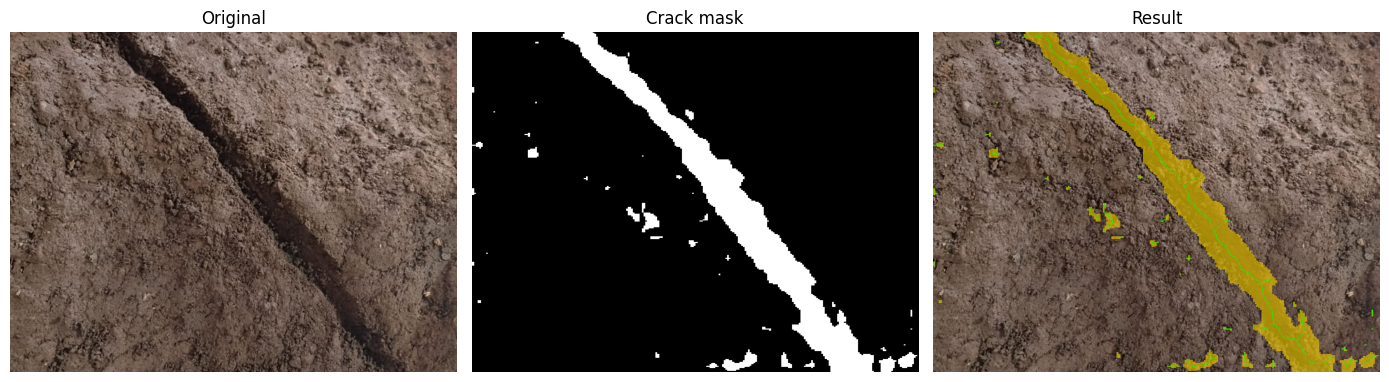

Done! If the crack is highlighted in gold, the model is working.


In [8]:
# ── CELL 8: Quick test on one image ───────────────────────────
# Upload a test image to check the model works
from google.colab import files as colab_files
import math

print('Upload a test crack image...')
test_upload = colab_files.upload()
test_path   = list(test_upload.keys())[0]

MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)
STD  = np.array([0.229,0.224,0.225], dtype=np.float32)

def predict(img_bgr):
    h, w = img_bgr.shape[:2]
    img  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, (256,256)).astype(np.float32)/255
    img  = (img - MEAN) / STD
    t    = torch.from_numpy(img.transpose(2,0,1)).unsqueeze(0).float().to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(t)).squeeze().cpu().numpy()
    mask = (prob > 0.5).astype(np.uint8) * 255
    return cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

img  = cv2.imread(test_path)
mask = predict(img)

# Simple pixel measurement
from skimage.morphology import skeletonize
skel = skeletonize((mask>0).astype(bool)).astype(np.uint8)
pts  = np.column_stack(np.where(skel>0))
print(f'Skeleton pixels: {len(pts)}')

# Visualise
vis = img.copy()
vis[mask>0] = (vis[mask>0]*0.4 + np.array([0,215,255])*0.6).astype(np.uint8)
vis[skel>0] = [0,255,0]

fig, axes = plt.subplots(1, 3, figsize=(14,5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original')
axes[1].imshow(mask, cmap='gray');                   axes[1].set_title('Crack mask')
axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); axes[2].set_title('Result')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
print('Done! If the crack is highlighted in gold, the model is working.')